# Market and conventional ownership feature analysis

This notebook examines the predictors available before the tabular models are trained. It uses **only the training sample**, so validation and test outcomes cannot influence preprocessing or modeling decisions.

It examines:

1. feature coverage and missingness;
2. distributions, including detailed market-capitalization diagnostics, and the four planned logarithmic transformations;
3. correlations among candidate tabular predictors;
4. univariate associations with forward maximum drawdown; and
5. temporal stability across training quarters.

The feature set remains frozen: this notebook diagnoses the modeling inputs but does not select variables or modify saved data. The eight network predictors are audited separately and enter only in the later network-model comparison.

## 1. Setup and training sample

In [1]:
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns


project_root = Path.cwd().resolve()

while not (project_root / 'config' / 'paths.yaml').is_file():
    if project_root.parent == project_root:
        raise FileNotFoundError('Could not locate the project root.')
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)


target = 'future_max_drawdown_63d'
market_features = [
    'market_cap_usd',
    'average_daily_dollar_volume_63d',
    'return_21d',
    'momentum_252_21d',
    'volatility_63d',
    'downside_volatility_63d',
    'market_beta_252d',
    'maximum_drawdown_252d',
    'negative_return_share_63d',
]
ownership_features = [
    'institutional_holder_count',
    'total_reported_value_usd',
    'reported_ownership_hhi',
    'top_five_reported_ownership_share',
    'mean_owner_portfolio_weight',
    'maximum_owner_portfolio_weight',
    'manager_holder_share',
    'institutional_holder_count_change_percent',
    'total_reported_value_change_percent',
    'reported_ownership_hhi_change',
    'top_five_reported_ownership_share_change',
]
baseline_features = market_features + ownership_features
market_log_features = [
    'market_cap_usd',
    'average_daily_dollar_volume_63d',
]
ownership_log_features = [
    'institutional_holder_count',
    'total_reported_value_usd',
]
log_features = market_log_features + ownership_log_features
feature_labels = {
    'market_cap_usd': 'Market cap',
    'average_daily_dollar_volume_63d': 'Dollar volume',
    'return_21d': 'Return (21d)',
    'momentum_252_21d': 'Momentum',
    'volatility_63d': 'Volatility',
    'downside_volatility_63d': 'Downside volatility',
    'market_beta_252d': 'Market beta',
    'maximum_drawdown_252d': 'Past drawdown',
    'negative_return_share_63d': 'Negative-return share',
    'institutional_holder_count': 'Holder count',
    'total_reported_value_usd': 'Reported value',
    'reported_ownership_hhi': 'Ownership HHI',
    'top_five_reported_ownership_share': 'Top-five share',
    'mean_owner_portfolio_weight': 'Mean owner weight',
    'maximum_owner_portfolio_weight': 'Maximum owner weight',
    'manager_holder_share': 'Manager-holder share',
    'institutional_holder_count_change_percent': 'Holder-count change',
    'total_reported_value_change_percent': 'Reported-value change',
    'reported_ownership_hhi_change': 'Ownership-HHI change',
    'top_five_reported_ownership_share_change': 'Top-five-share change',
}

paths = get_paths_config()
sample_path = paths.processed / 'modeling' / 'modeling_sample.parquet'

if not sample_path.is_file():
    raise FileNotFoundError(f'Modeling sample not found: {sample_path}')

columns = [
    'report_period',
    'permno',
    'sample_split',
    target,
    *baseline_features,
]
sample = pd.read_parquet(sample_path, columns=columns)
training = sample.loc[sample['sample_split'].eq('train')].copy()

if training.empty:
    raise RuntimeError('The training sample is empty.')

set_matplotlib_style()

print(f'Training stock-quarters: {len(training):,}')
print(f'Training quarters: {training["report_period"].nunique():,}')
print(f'Training securities: {training["permno"].nunique():,}')
print(
    'Training period: '
    f'{training["report_period"].min():%Y-%m-%d} to '
    f'{training["report_period"].max():%Y-%m-%d}'
)

Training stock-quarters: 123,791
Training quarters: 34
Training securities: 5,701
Training period: 2013-06-30 to 2021-09-30


## 2. Feature coverage and distributions

The summary identifies missing values, low-variation variables, skewness, and extreme ranges. Percentiles describe the observed training data and do not alter it.

,feature,observations,missing_share,unique_values,p01,median,p99,skewness
0,market_cap_usd,"123,791",0.00%,"123,452",7.668e+06,7.943e+08,1.376e+11,24.89
1,average_daily_dollar_volume_63d,"123,791",0.00%,"123,791",1.117e+04,6.026e+06,7.488e+08,36.77
2,return_21d,"123,791",0.00%,"123,791",-0.3775,0.003986,0.5183,6.79
3,momentum_252_21d,"123,791",0.00%,"123,791",-0.8196,0.07443,2.647,12.57
4,volatility_63d,"123,791",0.00%,"123,791",0.111,0.362,1.971,9.08
5,downside_volatility_63d,"123,791",0.00%,"123,791",0.06574,0.2384,1.103,2.27
6,market_beta_252d,"123,791",0.00%,"123,791",-0.1919,1.021,2.518,0.30
7,maximum_drawdown_252d,"123,791",0.00%,"117,168",0.07143,0.3061,0.9077,0.77
8,negative_return_share_63d,"123,791",0.00%,106,0.3333,0.4762,0.6349,0.03


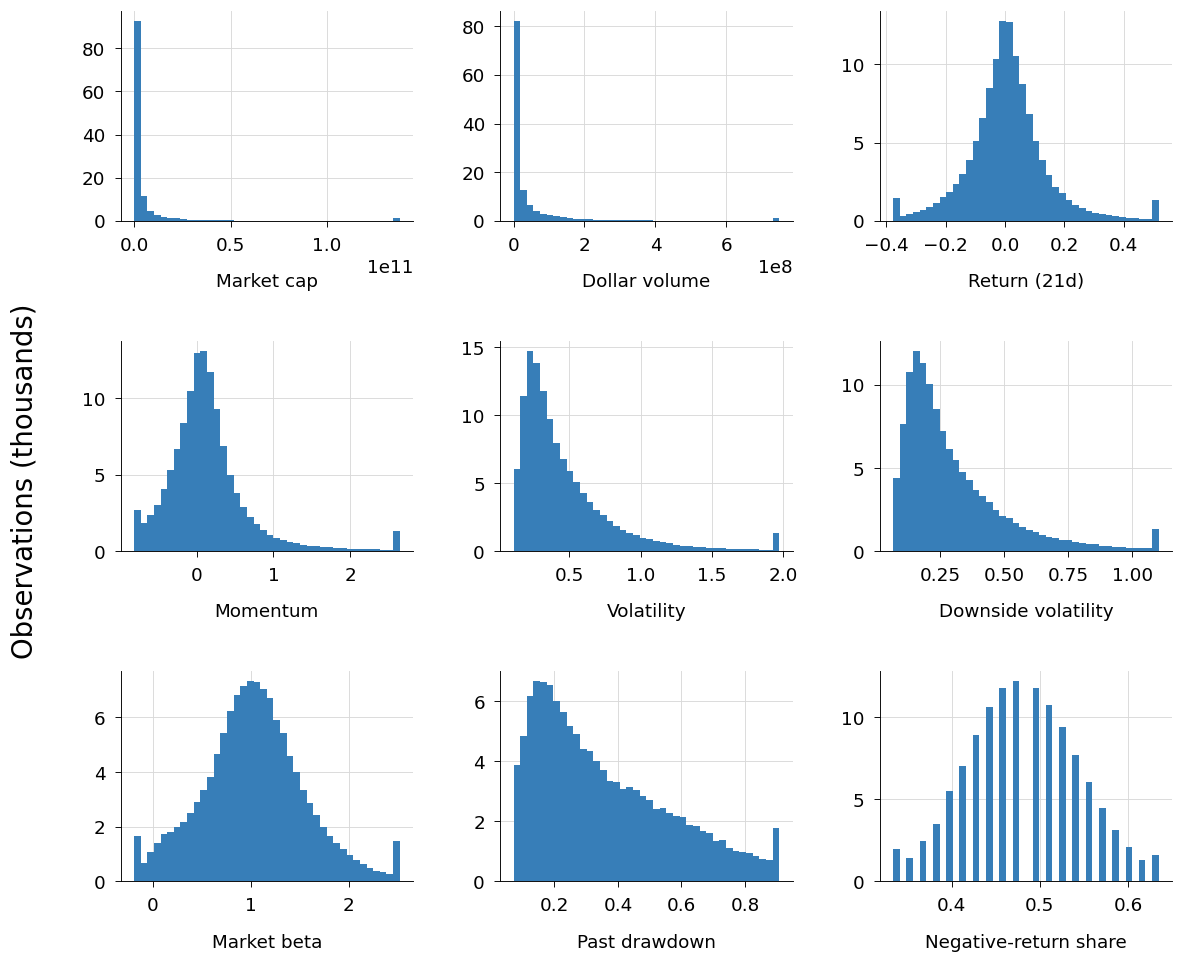

,feature,observations,missing_share,unique_values,p01,median,p99,skewness
9,institutional_holder_count,"123,791",0.00%,"2,121",4,103,1414,4.18
10,total_reported_value_usd,"123,791",0.00%,"116,324",1.709e+05,5.659e+08,2.368e+11,18.01
11,reported_ownership_hhi,"123,791",0.00%,"123,484",0.03559,0.1117,0.9722,1.91
12,top_five_reported_ownership_share,"123,791",0.00%,"120,674",0.3257,0.622,1,0.26
13,mean_owner_portfolio_weight,"123,791",0.00%,"123,784",3.465e-06,0.00232,0.02292,9.65
14,maximum_owner_portfolio_weight,"123,791",0.00%,"120,316",1.319e-05,0.05892,1,2.68
15,manager_holder_share,"123,791",0.00%,"21,762",0.0008612,0.02688,0.3608,3.75
16,institutional_holder_count_change_percent,"120,052",3.02%,"20,166",-33.33,1.282,75,14.14
17,total_reported_value_change_percent,"120,052",3.02%,"119,768",-94.53,1.88,1640,346.38
18,reported_ownership_hhi_change,"120,052",3.02%,"119,965",-0.7611,0.0001774,0.7274,-0.22


C:\Users\salio\AppData\Local\Temp\ipykernel_13928\22668978.py:53: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  display_values = values.clip(


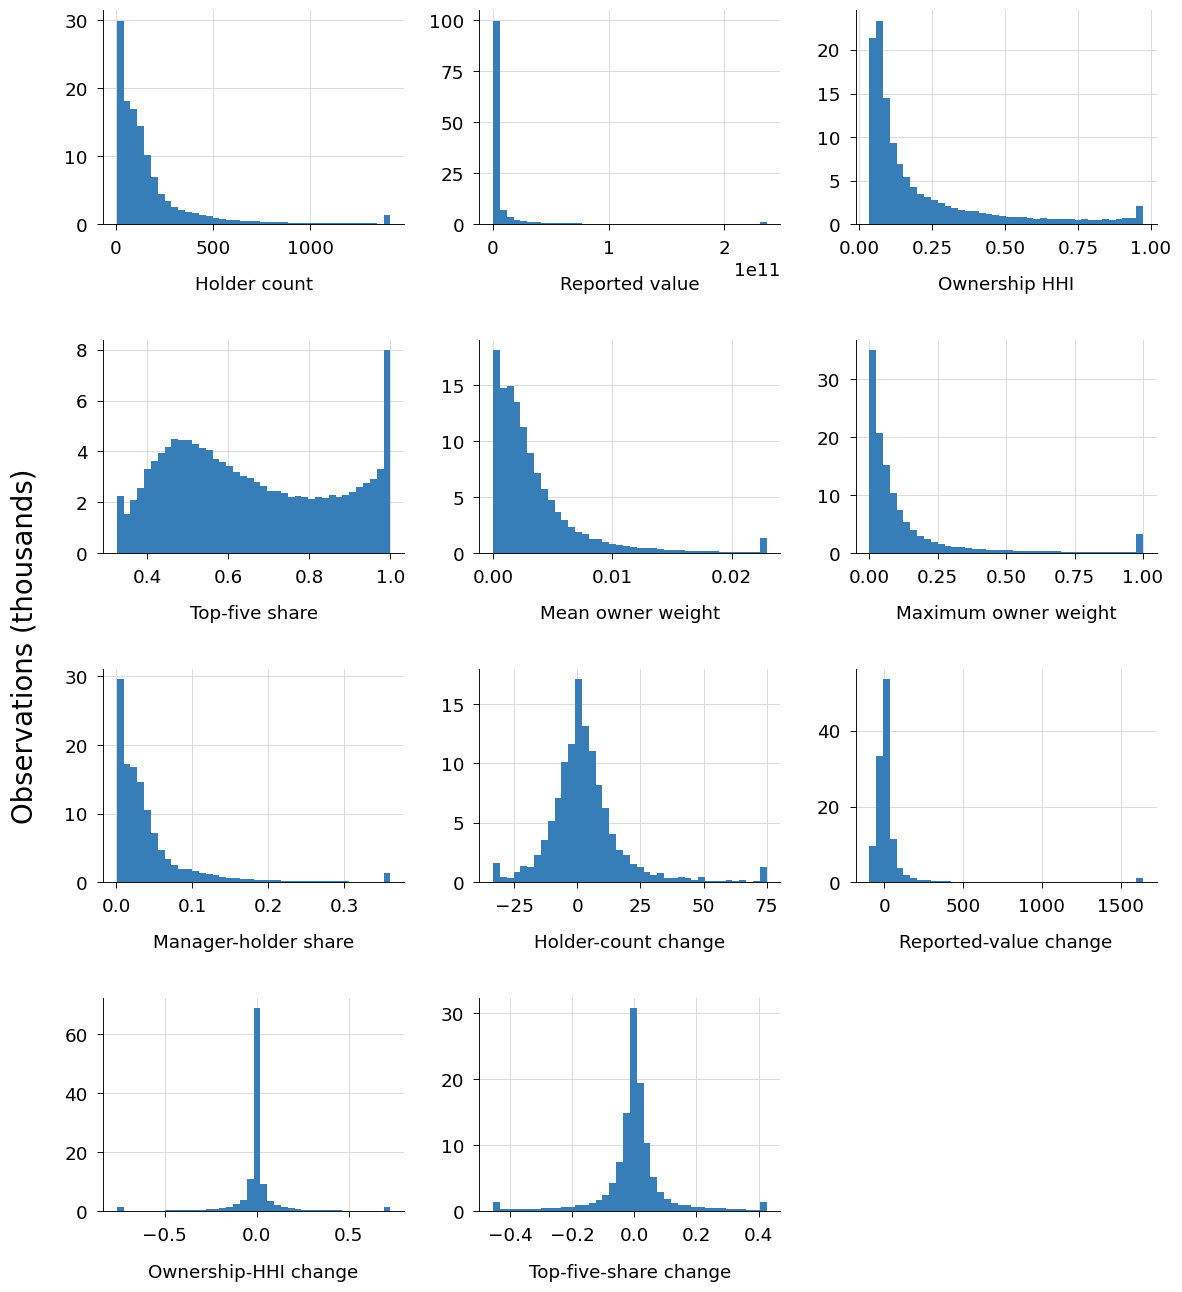

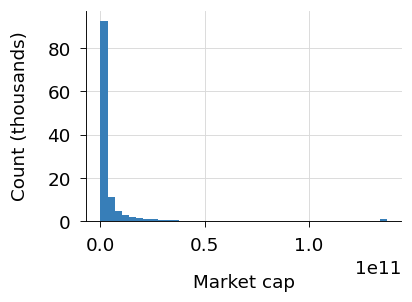

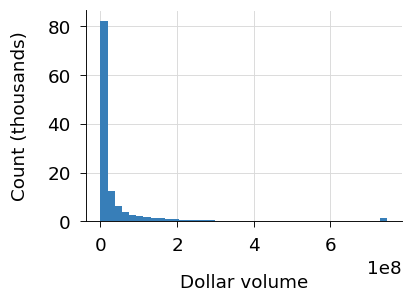

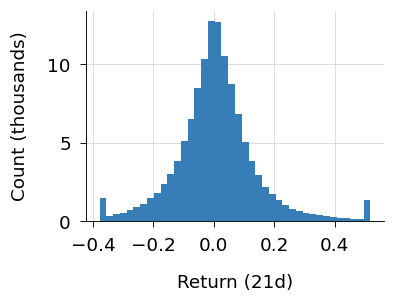

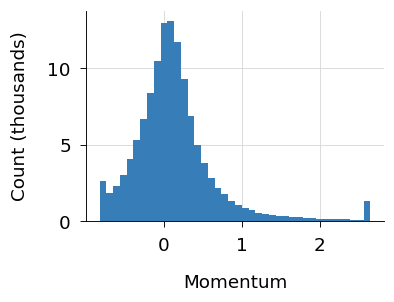

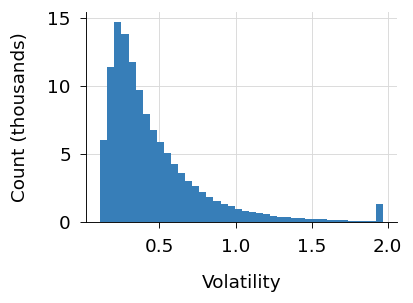

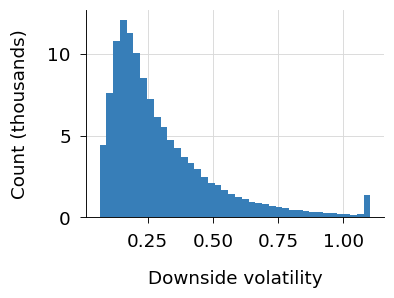

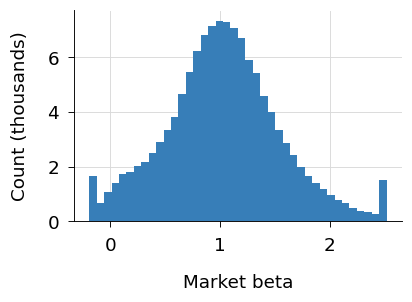

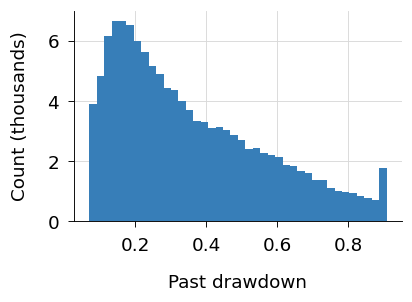

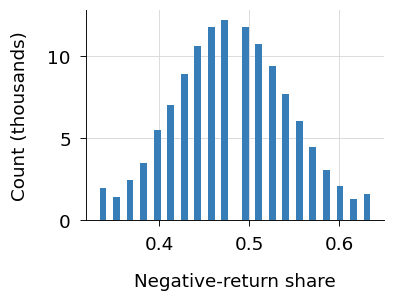

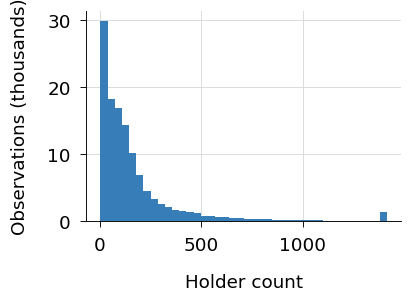

C:\Users\salio\AppData\Local\Temp\ipykernel_13928\22668978.py:98: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  display_values = values.clip(


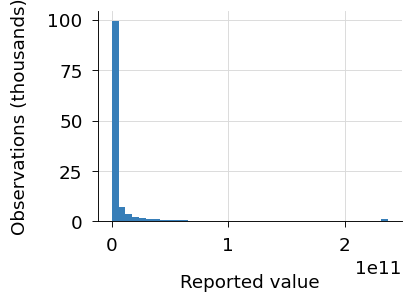

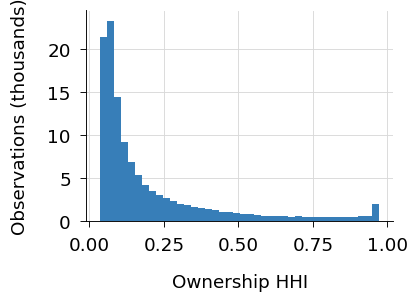

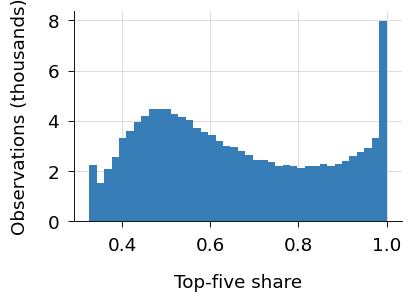

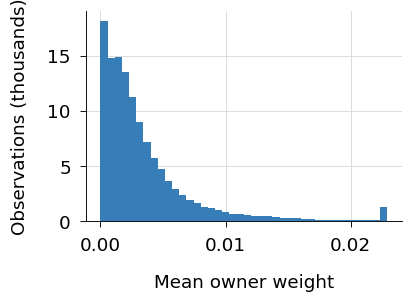

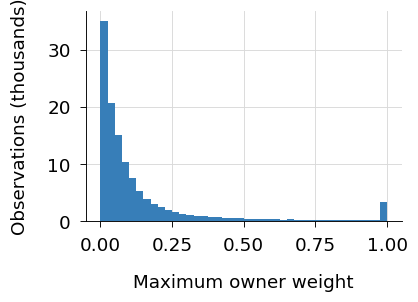

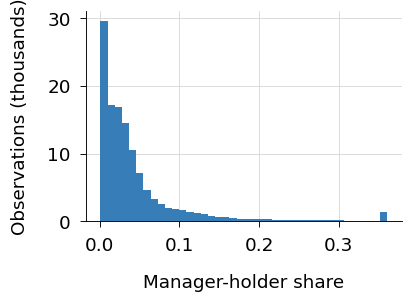

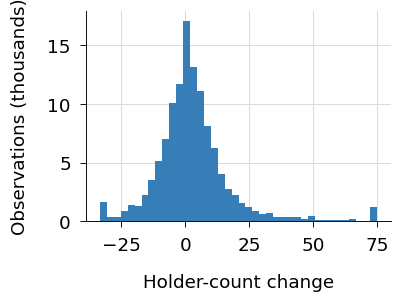

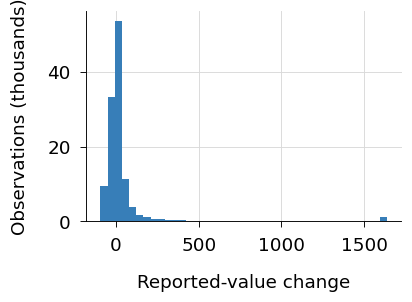

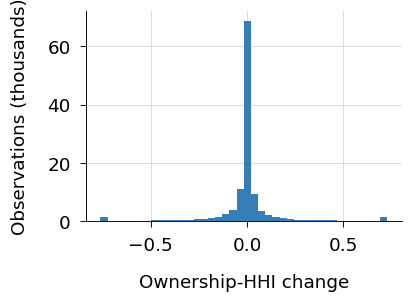

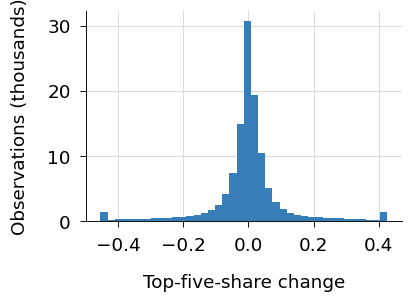

In [2]:
feature_summary = pd.DataFrame(
    {
        'group': [
            *(['Market'] * len(market_features)),
            *(['Ownership'] * len(ownership_features)),
        ],
        'feature': baseline_features,
        'observations': training[baseline_features].count().to_numpy(),
        'missing_share': training[baseline_features].isna().mean().to_numpy(),
        'unique_values': training[baseline_features].nunique().to_numpy(),
        'p01': training[baseline_features].quantile(0.01).to_numpy(),
        'median': training[baseline_features].median().to_numpy(),
        'p99': training[baseline_features].quantile(0.99).to_numpy(),
        'skewness': training[baseline_features].skew().to_numpy(),
    }
)

for group_name, features, shape, figure_size, output_name in [
    (
        'Market',
        market_features,
        (3, 3),
        (11, 9),
        '04_00_market_feature_distributions.pdf',
    ),
    (
        'Ownership',
        ownership_features,
        (4, 3),
        (11, 12),
        '04_00_ownership_feature_distributions.pdf',
    ),
]:
    display(
        feature_summary.loc[feature_summary['group'].eq(group_name)]
        .drop(columns='group')
        .style.format(
            {
                'observations': '{:,}',
                'missing_share': '{:.2%}',
                'unique_values': '{:,}',
                'p01': '{:.4g}',
                'median': '{:.4g}',
                'p99': '{:.4g}',
                'skewness': '{:.2f}',
            }
        )
    )

    figure, axes = plt.subplots(*shape, figsize=figure_size)
    for axis, feature in zip(axes.flat, features):
        values = training[feature].dropna()
        display_values = values.clip(
            lower=values.quantile(0.01),
            upper=values.quantile(0.99),
        )
        axis.hist(
            display_values,
            bins=40,
            weights=np.full(len(display_values), 1 / 1_000),
            color=COLOR_PALETTE[0],
        )
        axis.set_xlabel(feature_labels[feature])

    for axis in axes.flat[len(features):]:
        axis.set_visible(False)

    figure.supylabel('Observations (thousands)')
    apply_matplotlib_layout(figure)
    figure.savefig(paths.figures / output_name)
    plt.show()

for index, feature in enumerate(market_features, start=1):
    values = training[feature].dropna()
    display_values = values.clip(
        lower=values.quantile(0.01),
        upper=values.quantile(0.99),
    )

    figure, axis = plt.subplots(figsize=(4, 3))
    axis.hist(
        display_values,
        bins=40,
        weights=np.full(len(display_values), 1 / 1_000),
        color=COLOR_PALETTE[0],
    )
    axis.set_xlabel(feature_labels[feature])
    axis.set_ylabel('Count (thousands)')
    apply_matplotlib_layout(figure)
    figure.savefig(
        paths.figures
        / f'04_00_market_feature_distribution_{index:02d}_{feature}.pdf'
    )
    plt.show()

for index, feature in enumerate(ownership_features, start=1):
    values = training[feature].dropna()
    display_values = values.clip(
        lower=values.quantile(0.01),
        upper=values.quantile(0.99),
    )

    figure, axis = plt.subplots(figsize=(4, 3))
    axis.hist(
        display_values,
        bins=40,
        weights=np.full(len(display_values), 1 / 1_000),
        color=COLOR_PALETTE[0],
    )
    axis.set_xlabel(feature_labels[feature])
    axis.set_ylabel('Observations (thousands)')
    apply_matplotlib_layout(figure)
    figure.savefig(
        paths.figures
        / f'04_00_ownership_feature_distribution_{index:02d}_{feature}.pdf'
    )
    plt.show()

## 3. Missingness

Only nonzero missingness is plotted. Missing predictor values are not filled here; the model pipeline must estimate imputation values from its fitting sample.

In [3]:
missingness = (
    feature_summary.loc[
        feature_summary['missing_share'].gt(0),
        ['group', 'feature', 'missing_share'],
    ]
    .sort_values('missing_share')
)

for group_name in ['Market', 'Ownership']:
    display(
        missingness.loc[missingness['group'].eq(group_name)]
        .drop(columns='group')
        .style.format({'missing_share': '{:.2%}'})
    )

feature_summary.loc[feature_summary['group'].eq('Market')].to_csv(
    paths.tables / '04_00_market_feature_summary.csv', index=False
)
feature_summary.loc[feature_summary['group'].eq('Ownership')].to_csv(
    paths.tables / '04_00_ownership_feature_summary.csv', index=False
)

,feature,missing_share


,feature,missing_share
16,institutional_holder_count_change_percent,3.02%
17,total_reported_value_change_percent,3.02%
18,reported_ownership_hhi_change,3.02%
19,top_five_reported_ownership_share_change,3.02%


## 4. Planned logarithmic transformations

The tabular pipeline applies `log1p` to two market scale variables and two ownership scale variables. Separate figures compare each raw distribution with its transformed version. Raw panels are capped at their 99th percentile **for display only**; the modeling pipeline separately estimates its clipping bounds from the fitting sample.

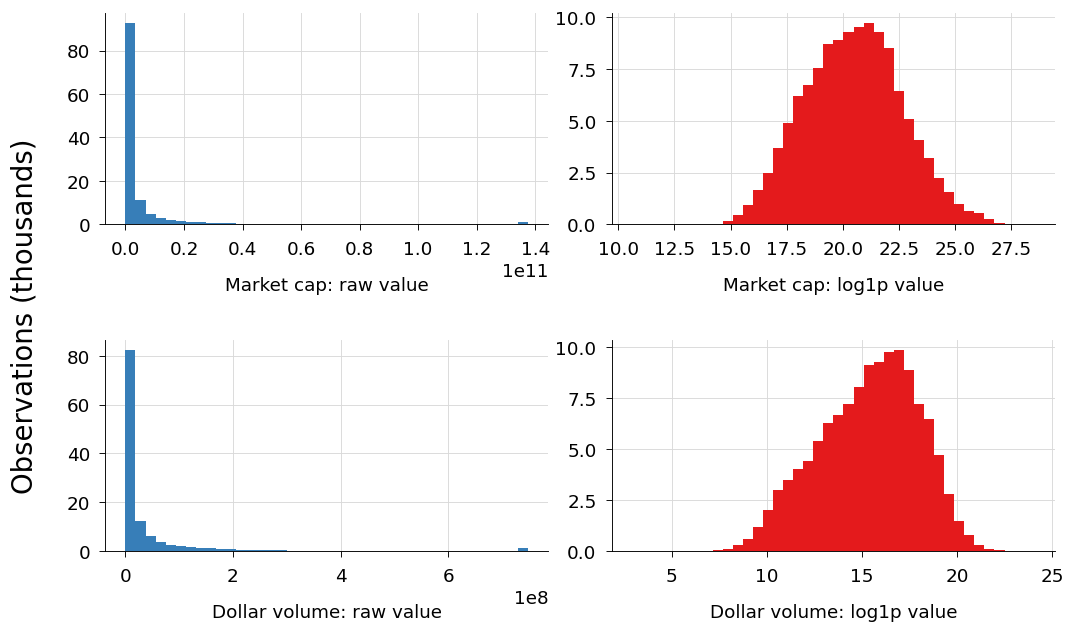

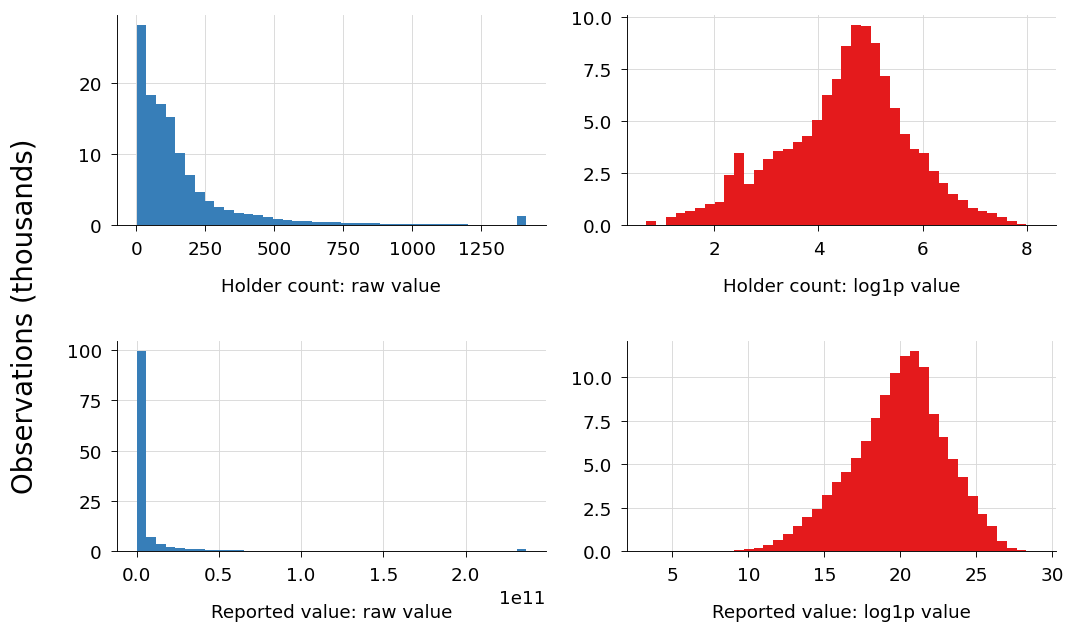

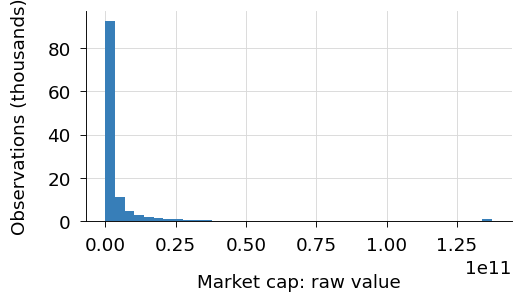

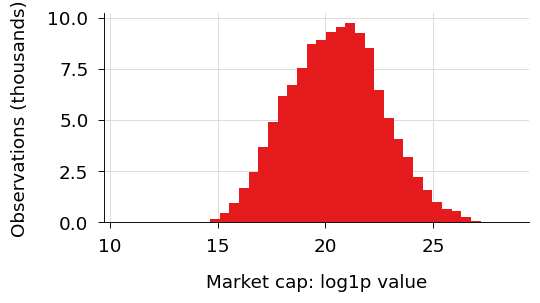

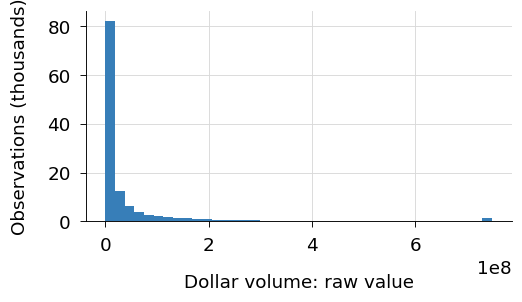

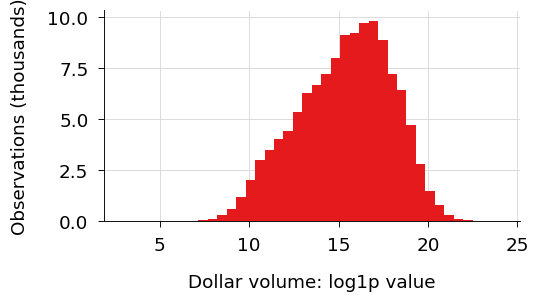

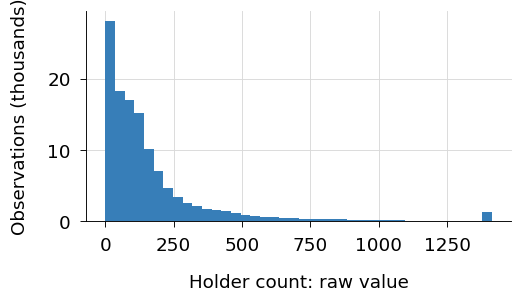

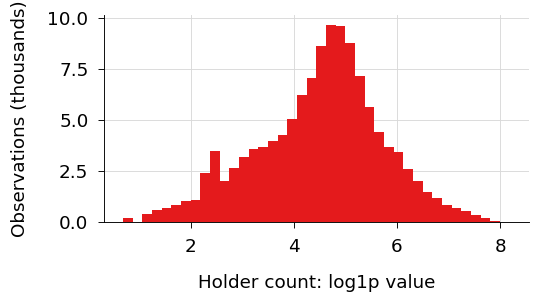

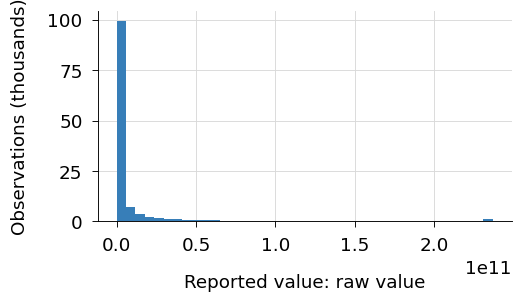

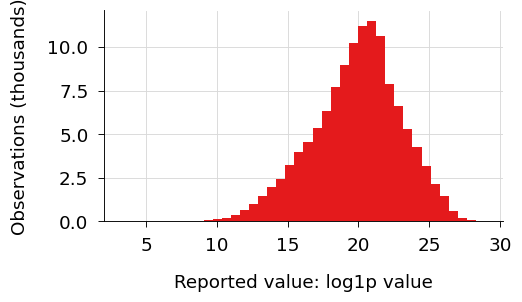

In [4]:
for features, output_name in [
    (market_log_features, '04_00_market_log_transformations.pdf'),
    (ownership_log_features, '04_00_ownership_log_transformations.pdf'),
]:
    figure, axes = plt.subplots(len(features), 2, figsize=(10, 6))

    for row, feature in enumerate(features):
        values = training[feature].dropna()
        raw_display = values.clip(upper=values.quantile(0.99))

        axes[row, 0].hist(
            raw_display,
            bins=40,
            weights=np.full(len(raw_display), 1 / 1_000),
            color=COLOR_PALETTE[0],
        )
        axes[row, 0].set_xlabel(f'{feature_labels[feature]}: raw value')

        axes[row, 1].hist(
            np.log1p(values),
            bins=40,
            weights=np.full(len(values), 1 / 1_000),
            color=COLOR_PALETTE[1],
        )
        axes[row, 1].set_xlabel(f'{feature_labels[feature]}: log1p value')

    figure.supylabel('Observations (thousands)')
    apply_matplotlib_layout(figure)
    figure.savefig(paths.figures / output_name)
    plt.show()

for group_name, features in [
    ('market', market_log_features),
    ('ownership', ownership_log_features),
]:
    for feature_index, feature in enumerate(features, start=1):
        values = training[feature].dropna()
        raw_display = values.clip(upper=values.quantile(0.99))
        transformations = [
            (raw_display, 'raw', 'raw value', COLOR_PALETTE[0]),
            (np.log1p(values), 'log1p', 'log1p value', COLOR_PALETTE[1]),
        ]

        for transformation_index, (
            display_values,
            suffix,
            axis_label,
            color,
        ) in enumerate(transformations, start=1):
            panel_index = 2 * (feature_index - 1) + transformation_index
            figure, axis = plt.subplots(figsize=(5, 3))
            axis.hist(
                display_values,
                bins=40,
                weights=np.full(len(display_values), 1 / 1_000),
                color=color,
            )
            axis.set_xlabel(f'{feature_labels[feature]}: {axis_label}')
            axis.set_ylabel('Observations (thousands)')
            apply_matplotlib_layout(figure)
            figure.savefig(
                paths.figures
                / (
                    f'04_00_{group_name}_log_transformation_'
                    f'{panel_index:02d}_{feature}_{suffix}.pdf'
                )
            )
            plt.show()

### Market-capitalization detail

The following statistics describe market capitalization in the training sample only. The quarterly percentiles show how its cross-sectional distribution changes over time; they are descriptive and do not define alternative modeling universes.

,USD billions
Observations,"123,791.000"
Mean,7.736
Standard deviation,40.508
Minimum,0.000
P1,0.008
P5,0.023
P10,0.045
P25,0.165
Median,0.794
P75,3.467


,Distribution,Skewness
0,Raw market capitalization,24.89
1,Log-transformed market capitalization,0.09


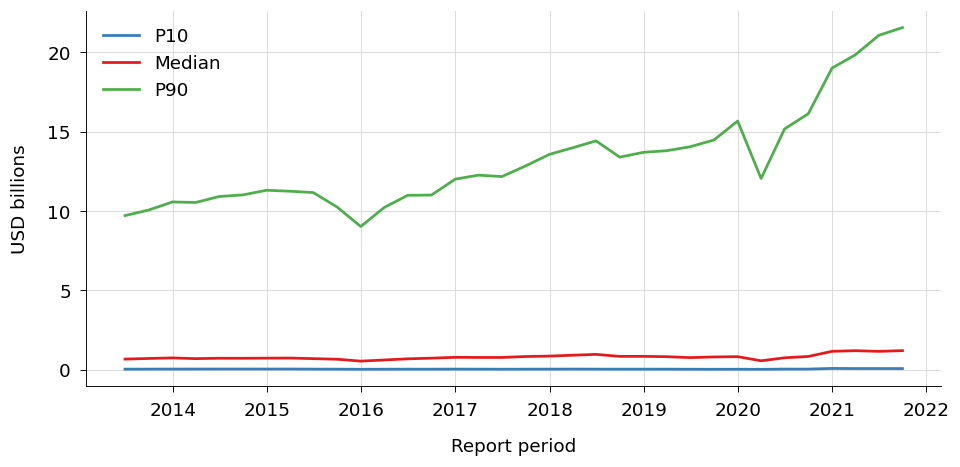

In [5]:
market_cap_billions = training['market_cap_usd'].dropna() / 1e9
market_cap_statistics = market_cap_billions.describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).rename({
    'count': 'Observations',
    'mean': 'Mean',
    'std': 'Standard deviation',
    'min': 'Minimum',
    '1%': 'P1',
    '5%': 'P5',
    '10%': 'P10',
    '25%': 'P25',
    '50%': 'Median',
    '75%': 'P75',
    '90%': 'P90',
    '95%': 'P95',
    '99%': 'P99',
    'max': 'Maximum',
}).rename('USD billions').to_frame()
display(market_cap_statistics.style.format('{:,.3f}'))

shape_statistics = pd.DataFrame({
    'Distribution': ['Raw market capitalization', 'Log-transformed market capitalization'],
    'Skewness': [
        training['market_cap_usd'].skew(),
        np.log1p(training['market_cap_usd']).skew(),
    ],
})
display(shape_statistics.style.format({'Skewness': '{:.2f}'}))

quarterly_market_cap = (
    training.groupby('report_period')['market_cap_usd']
    .quantile([0.10, 0.50, 0.90])
    .unstack()
    .div(1e9)
)
quarterly_market_cap.columns = ['P10', 'Median', 'P90']

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
for color, column in zip(COLOR_PALETTE, quarterly_market_cap.columns):
    axis.plot(
        pd.to_datetime(quarterly_market_cap.index),
        quarterly_market_cap[column],
        color=color,
        label=column,
    )
axis.legend()
axis.set(
    xlabel='Report period',
    ylabel='USD billions',
)
axis.xaxis.set_major_locator(mdates.YearLocator())
axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "04_00_market_cap_over_time.pdf")
plt.show()

## 5. Predictor correlations

Spearman correlations summarize monotonic dependence while remaining less sensitive to skewness and extreme observations than Pearson correlations. High correlation is a diagnostic, not an automatic variable-removal rule.

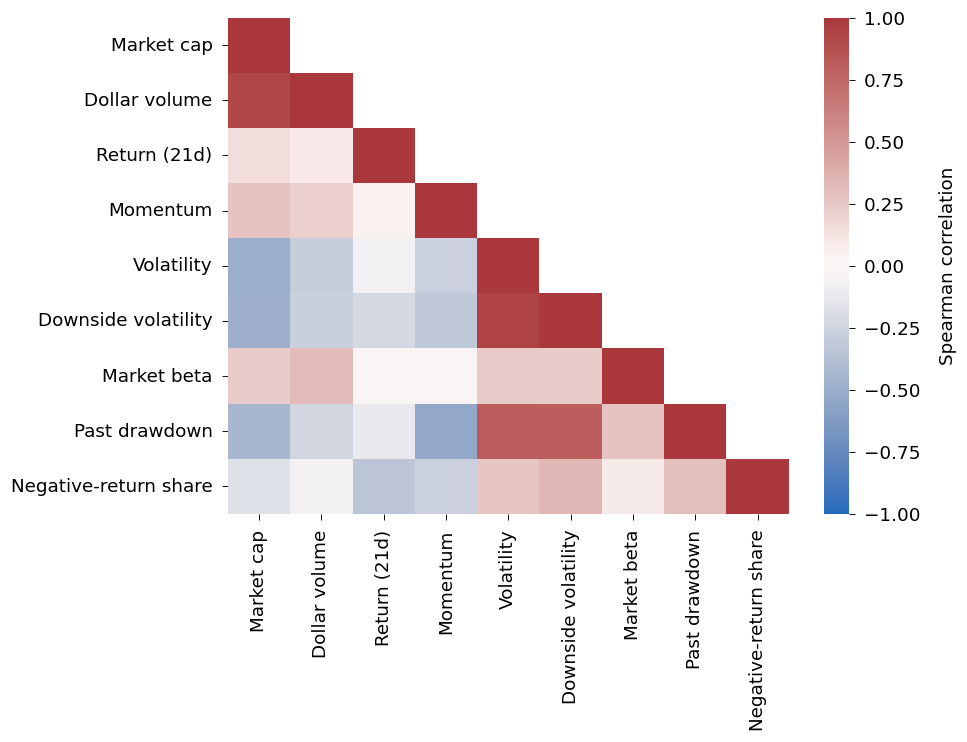

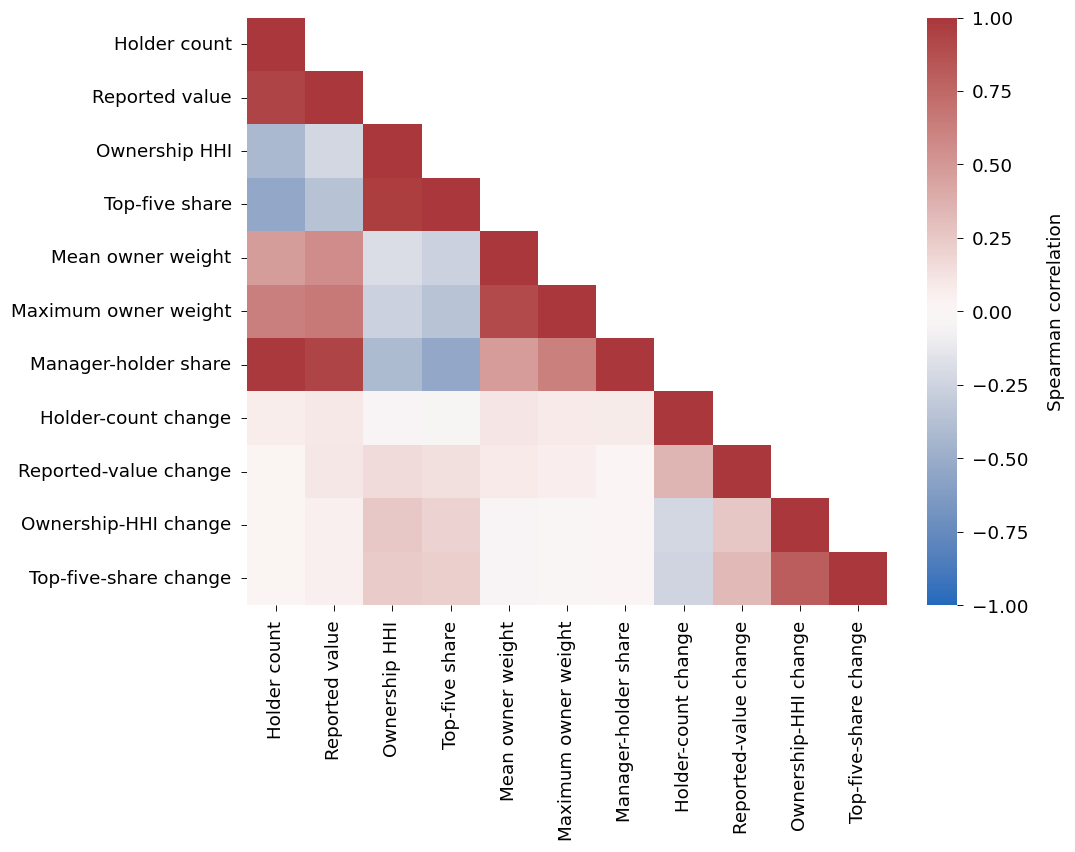

,group,feature_1,feature_2,spearman
1,Market,Volatility,Downside volatility,0.942
0,Market,Market cap,Dollar volume,0.925
2,Market,Volatility,Past drawdown,0.808
3,Market,Downside volatility,Past drawdown,0.803
5,Ownership,Holder count,Manager-holder share,0.987
7,Ownership,Ownership HHI,Top-five share,0.967
6,Ownership,Reported value,Manager-holder share,0.932
4,Ownership,Holder count,Reported value,0.930
8,Ownership,Mean owner weight,Maximum owner weight,0.901
9,Ownership,Ownership-HHI change,Top-five-share change,0.810


In [6]:
correlation_summaries = []
for group_name, features, figure_size, output_name in [
    (
        'Market',
        market_features,
        (9, 7),
        '04_00_market_feature_correlations.pdf',
    ),
    (
        'Ownership',
        ownership_features,
        (10, 8),
        '04_00_ownership_feature_correlations.pdf',
    ),
]:
    correlations = training[features].corr(method='spearman').rename(
        index=feature_labels,
        columns=feature_labels,
    )
    mask = np.triu(np.ones_like(correlations, dtype=bool), k=1)

    figure, axis = plt.subplots(figsize=figure_size)
    sns.heatmap(
        correlations,
        mask=mask,
        cmap='vlag',
        center=0,
        vmin=-1,
        vmax=1,
        cbar_kws={'label': 'Spearman correlation'},
        ax=axis,
    )
    axis.grid(False)
    apply_matplotlib_layout(figure)
    figure.savefig(paths.figures / output_name)
    plt.show()

    upper_triangle = correlations.where(
        np.triu(np.ones_like(correlations, dtype=bool), k=1)
    )
    strong_pairs = (
        upper_triangle.stack()
        .rename('spearman')
        .reset_index()
        .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
    )
    strong_pairs = strong_pairs.loc[
        strong_pairs['spearman'].abs().ge(0.80)
    ].copy()
    strong_pairs.insert(0, 'group', group_name)
    correlation_summaries.append(strong_pairs)

strong_correlations = pd.concat(correlation_summaries, ignore_index=True)
strong_correlations = (
    strong_correlations.assign(
        absolute_correlation=strong_correlations['spearman'].abs()
    )
    .sort_values(['group', 'absolute_correlation'], ascending=[True, False])
    .drop(columns='absolute_correlation')
)
display(strong_correlations.style.format({'spearman': '{:.3f}'}))

## 6. Univariate target associations

For each feature, the Spearman correlation with the target is calculated separately in every training quarter and then averaged across quarters. These associations do not measure incremental predictive value once the other predictors are included.

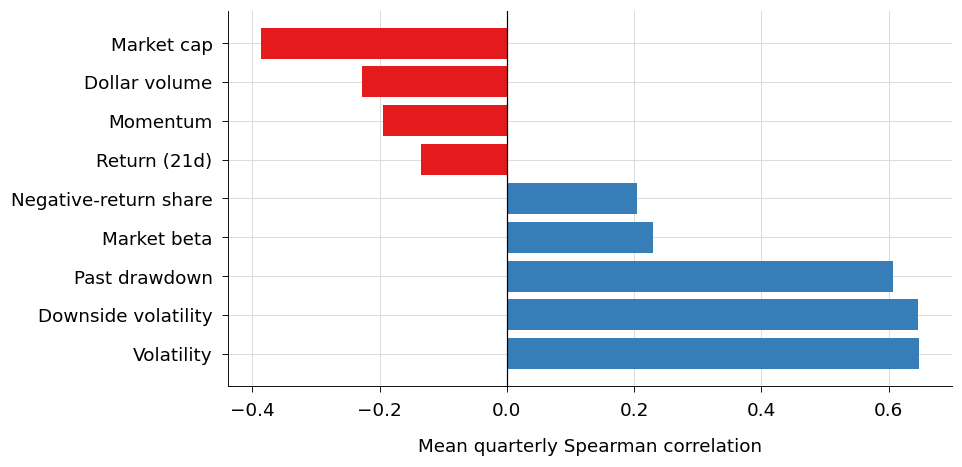

,spearman
Market cap,-0.386
Dollar volume,-0.227
Momentum,-0.194
Return (21d),-0.135
Negative-return share,0.205
Market beta,0.230
Past drawdown,0.607
Downside volatility,0.646
Volatility,0.647


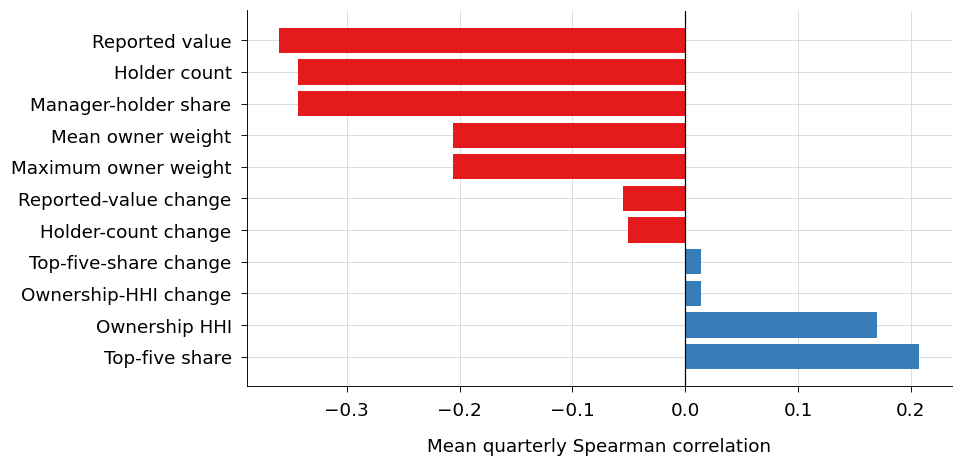

,spearman
Reported value,-0.360
Holder count,-0.343
Manager-holder share,-0.343
Mean owner weight,-0.206
Maximum owner weight,-0.205
Reported-value change,-0.055
Holder-count change,-0.051
Top-five-share change,0.014
Ownership-HHI change,0.014
Ownership HHI,0.170


In [7]:
target_associations = {}
for group_name, features, output_name in [
    (
        'Market',
        market_features,
        '04_00_market_target_associations.pdf',
    ),
    (
        'Ownership',
        ownership_features,
        '04_00_ownership_target_associations.pdf',
    ),
]:
    quarterly_correlations = pd.DataFrame(
        {
            feature: training.groupby('report_period').apply(
                lambda quarter: quarter[feature].corr(
                    quarter[target], method='spearman'
                ),
                include_groups=False,
            )
            for feature in features
        }
    )
    associations = (
        quarterly_correlations.mean()
        .rename(index=feature_labels)
        .sort_values()
    )
    target_associations[group_name] = associations
    bar_colors = [
        COLOR_PALETTE[1] if value < 0 else COLOR_PALETTE[0]
        for value in associations
    ]

    figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
    axis.barh(associations.index, associations, color=bar_colors)
    axis.axvline(0, color='black', linewidth=0.8)
    axis.invert_yaxis()
    axis.set_xlabel('Mean quarterly Spearman correlation')
    axis.set_ylabel('')
    apply_matplotlib_layout(figure)
    figure.savefig(paths.figures / output_name)
    plt.show()

    display(associations.rename('spearman').to_frame().style.format('{:.3f}'))

## 7. Representative binned relationships

Within each training quarter, stocks are ranked into deciles separately for every market and ownership feature. Averaging the target within each decile reveals monotonicity and possible nonlinear relationships while controlling descriptively for changes in the cross-sectional scale over time.

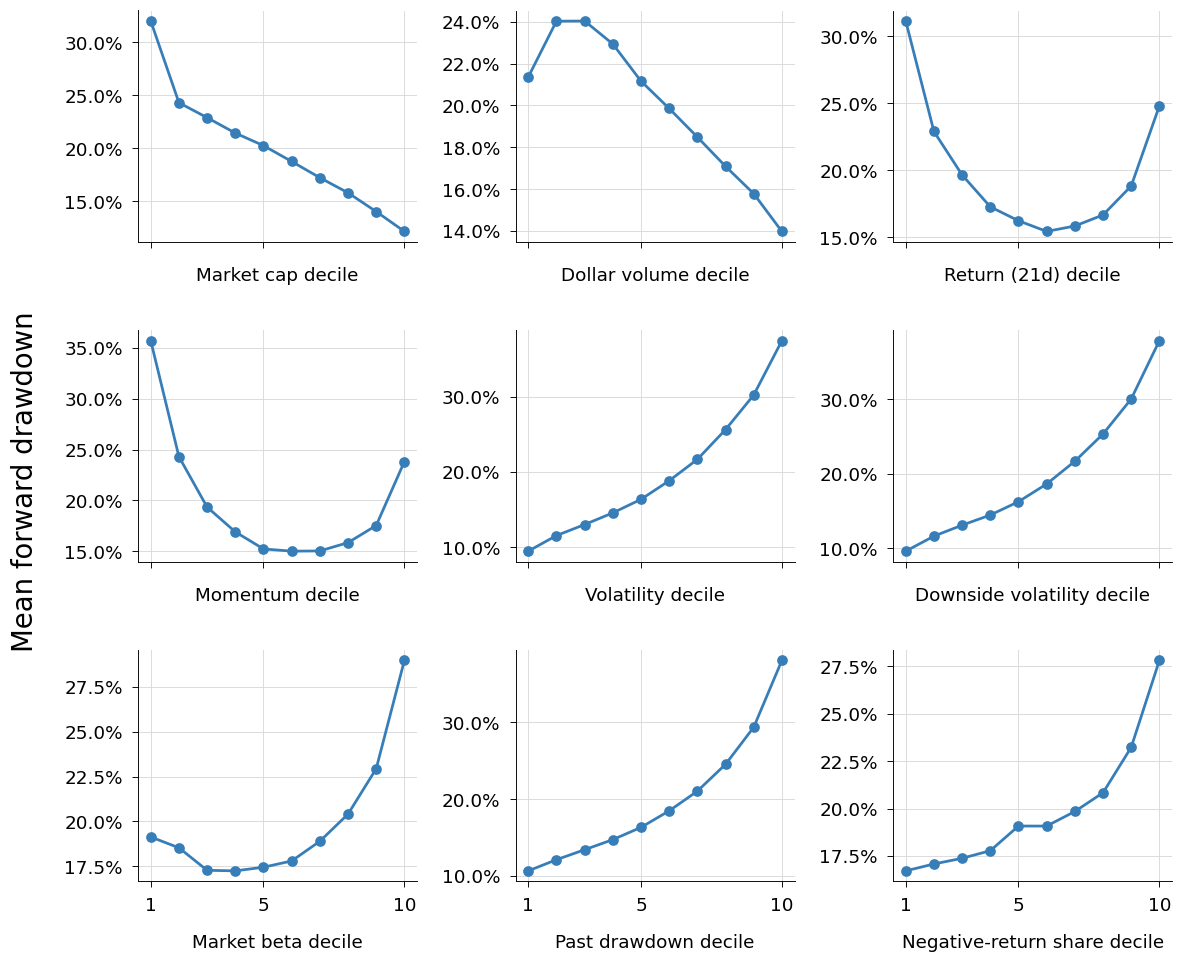

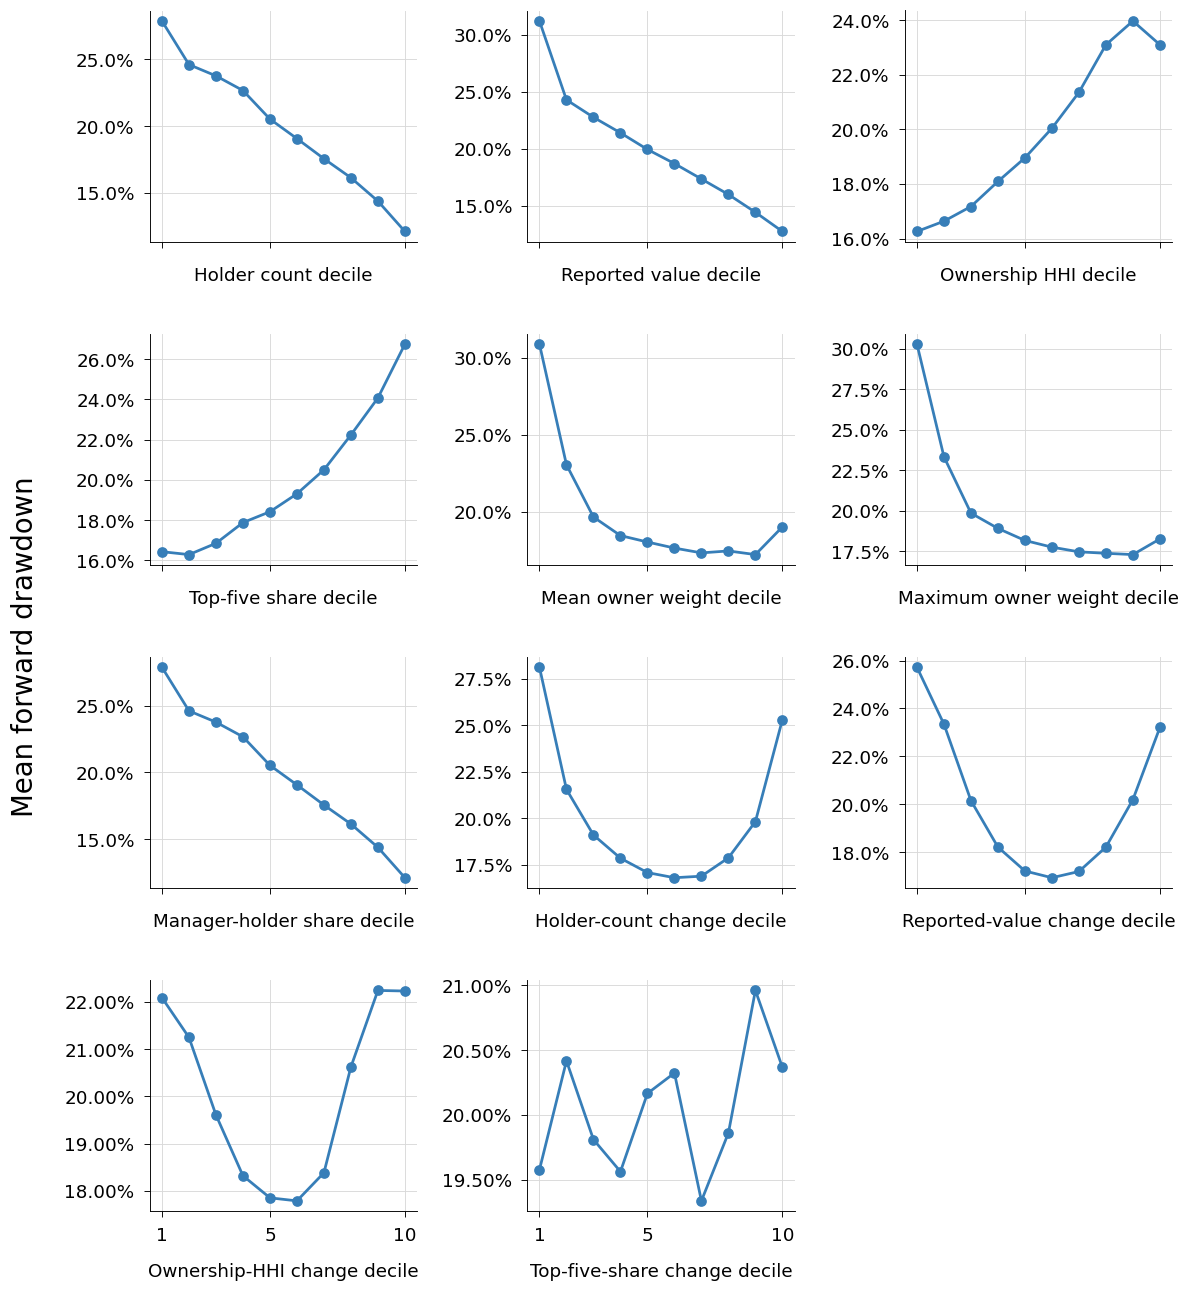

,group,feature,decile_1_drawdown,decile_10_drawdown,decile_10_minus_1
0,Market,Market cap,31.99%,12.14%,-19.86%
1,Market,Dollar volume,21.36%,13.97%,-7.38%
2,Market,Return (21d),31.15%,24.80%,-6.35%
3,Market,Momentum,35.69%,23.81%,-11.88%
4,Market,Volatility,9.48%,37.40%,+27.92%
5,Market,Downside volatility,9.62%,37.86%,+28.24%
6,Market,Market beta,19.14%,28.96%,+9.83%
7,Market,Past drawdown,10.64%,38.08%,+27.45%
8,Market,Negative-return share,16.71%,27.81%,+11.10%
9,Ownership,Holder count,27.86%,12.12%,-15.74%


In [8]:
relationship_rows = []
for group_name, features, shape, figure_size, output_name in [
    (
        'Market',
        market_features,
        (3, 3),
        (11, 9),
        '04_00_market_decile_relationships.pdf',
    ),
    (
        'Ownership',
        ownership_features,
        (4, 3),
        (11, 12),
        '04_00_ownership_decile_relationships.pdf',
    ),
]:
    figure, axes = plt.subplots(*shape, figsize=figure_size, sharex=True)

    for axis, feature in zip(axes.flat, features):
        percentile_rank = training.groupby('report_period')[feature].rank(
            method='average',
            pct=True,
        )
        feature_decile = np.ceil(percentile_rank * 10).clip(1, 10)
        relationship = (
            training.assign(feature_decile=feature_decile)
            .dropna(subset=['feature_decile'])
            .groupby('feature_decile', as_index=False)[target]
            .mean()
        )
        relationship_rows.append(
            {
                'group': group_name,
                'feature': feature_labels[feature],
                'decile_1_drawdown': relationship.loc[
                    relationship['feature_decile'].eq(1), target
                ].iloc[0],
                'decile_10_drawdown': relationship.loc[
                    relationship['feature_decile'].eq(10), target
                ].iloc[0],
            }
        )

        axis.plot(
            relationship['feature_decile'],
            relationship[target],
            marker='o',
            color=COLOR_PALETTE[0],
        )
        axis.set_xlabel(f'{feature_labels[feature]} decile')
        axis.set_xticks([1, 5, 10])
        axis.yaxis.set_major_formatter(PercentFormatter(1.0))

    for axis in axes.flat[len(features):]:
        axis.set_visible(False)

    figure.supylabel('Mean forward drawdown')
    apply_matplotlib_layout(figure)
    figure.savefig(paths.figures / output_name)
    plt.show()

relationship_summary = pd.DataFrame(relationship_rows)
relationship_summary['decile_10_minus_1'] = (
    relationship_summary['decile_10_drawdown']
    - relationship_summary['decile_1_drawdown']
)
display(
    relationship_summary.style.format(
        {
            'decile_1_drawdown': '{:.2%}',
            'decile_10_drawdown': '{:.2%}',
            'decile_10_minus_1': '{:+.2%}',
        }
    )
)

## 8. Temporal stability

Quarterly medians are shown separately for every market and ownership feature to reveal broad time variation or abrupt shifts. The four scale variables are shown after `log1p` so that their evolution remains readable.

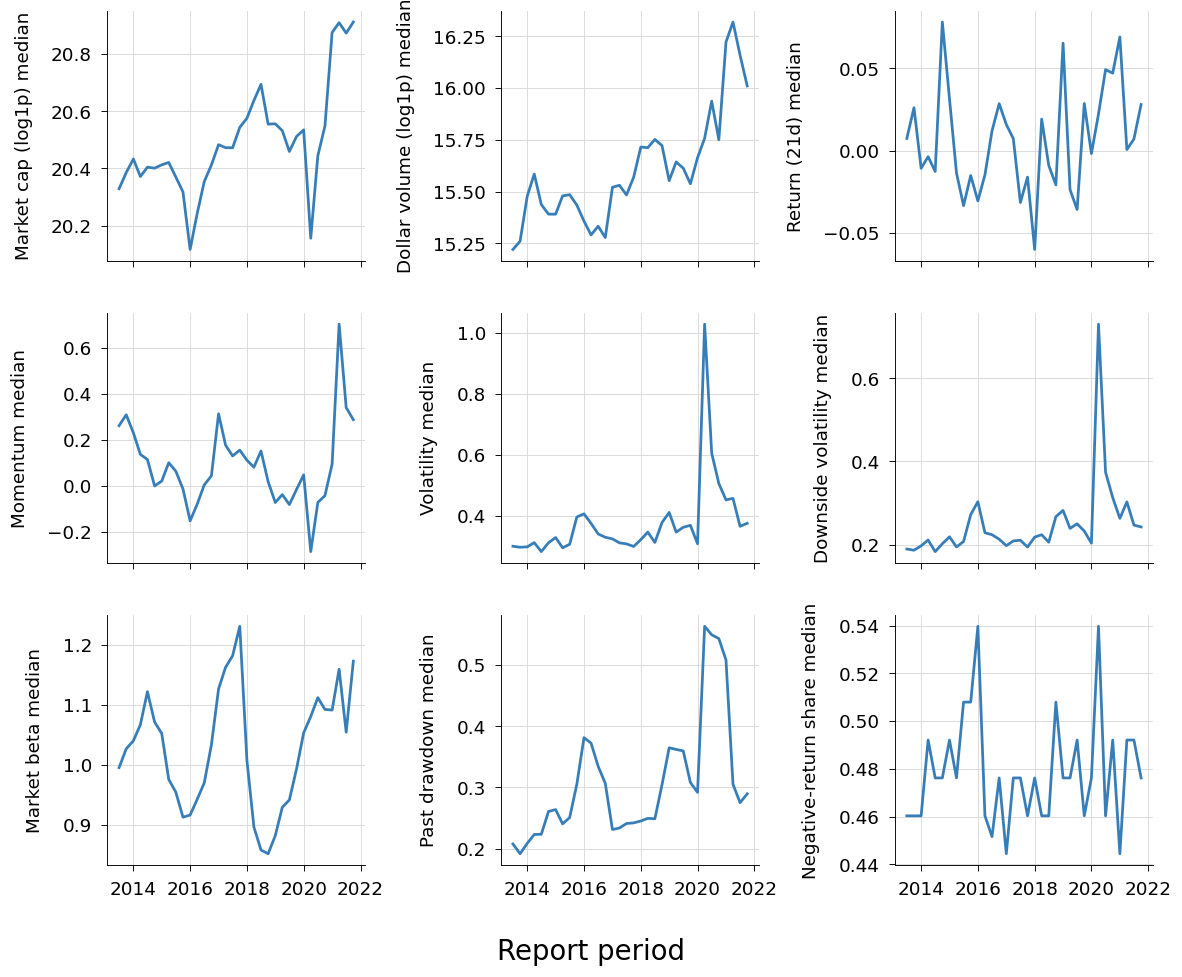

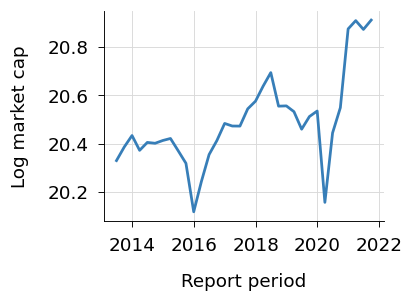

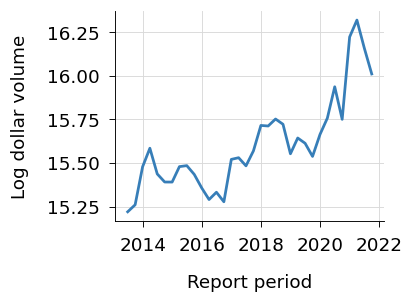

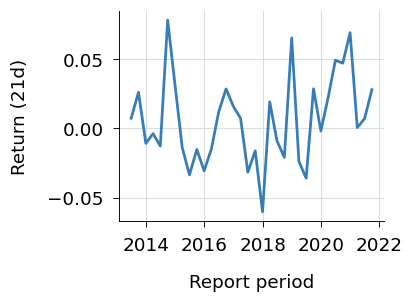

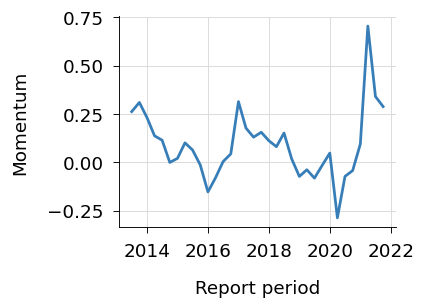

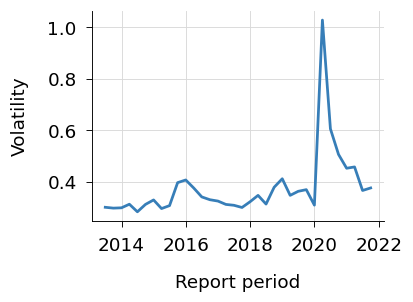

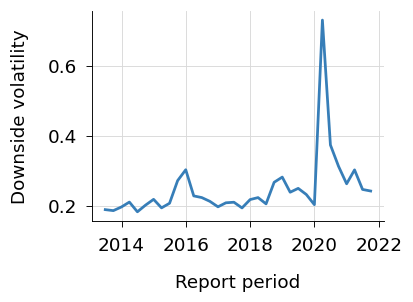

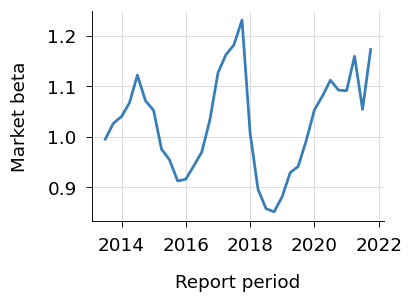

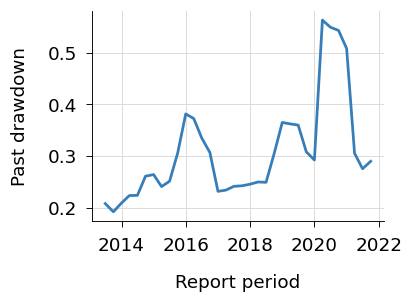

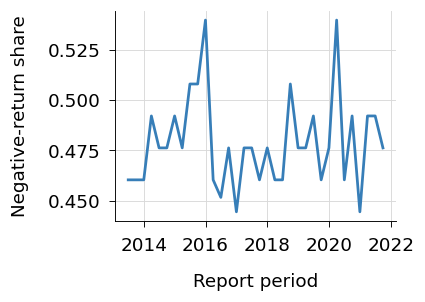

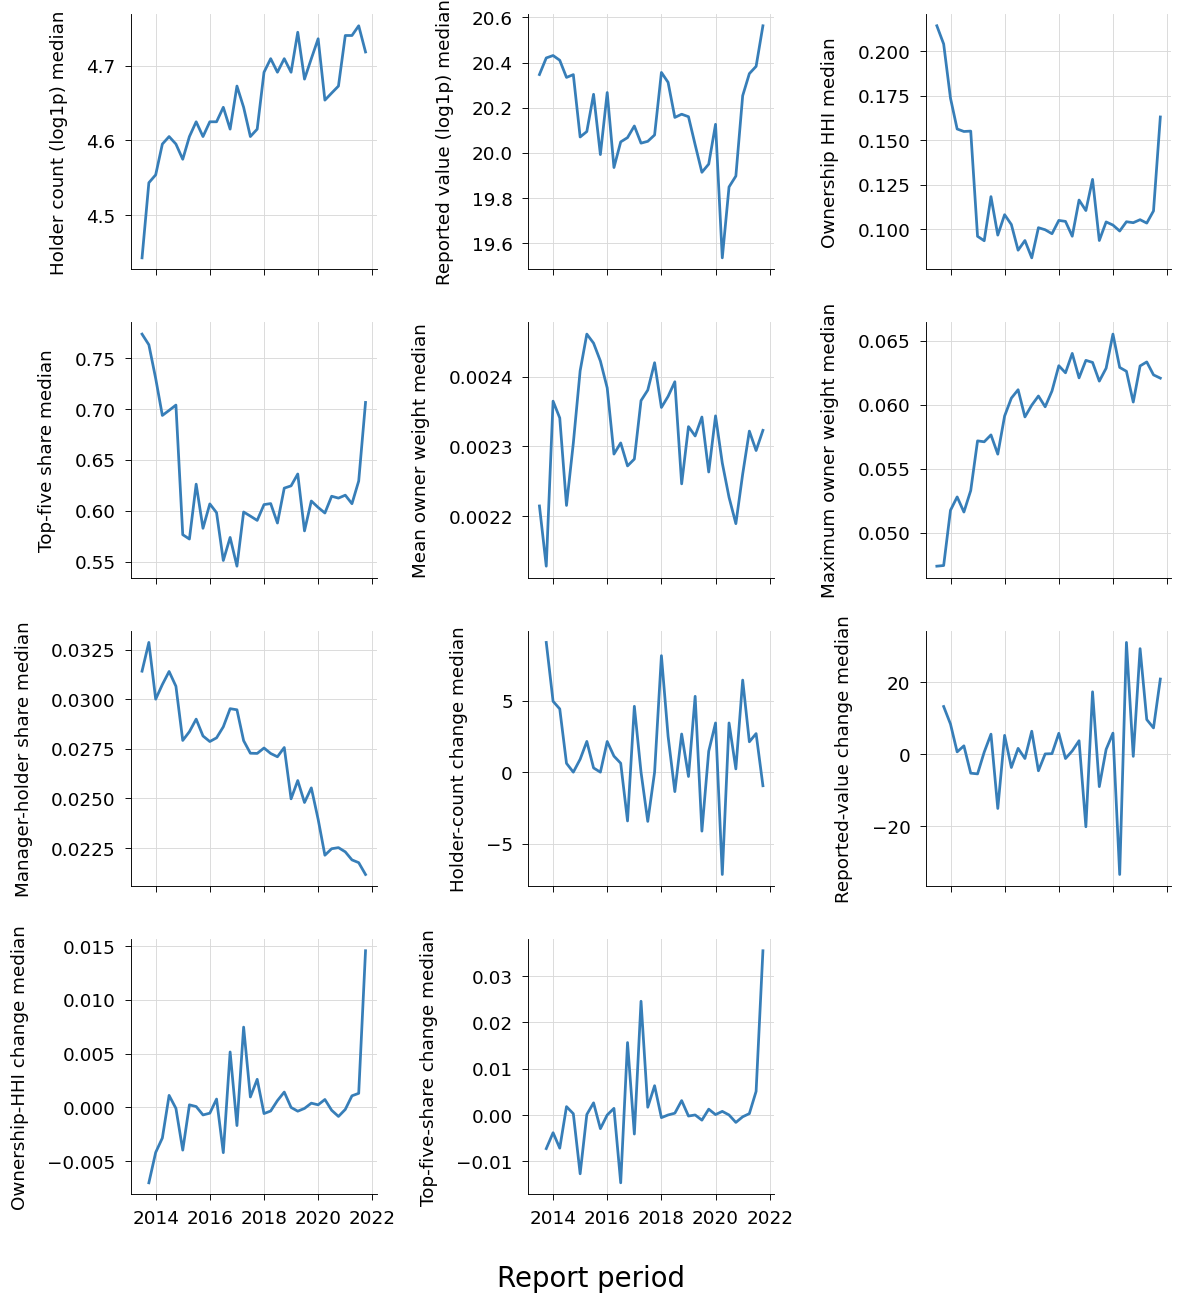

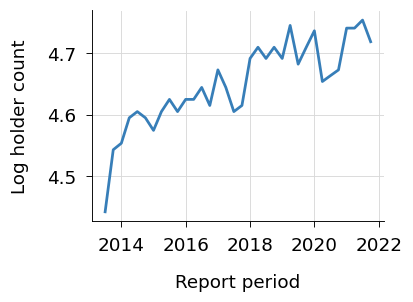

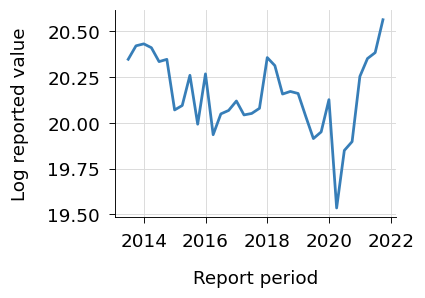

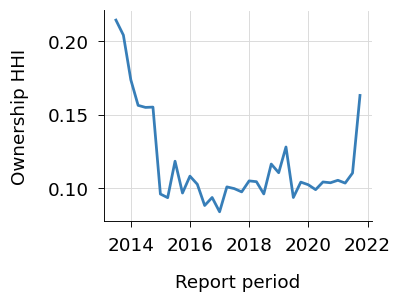

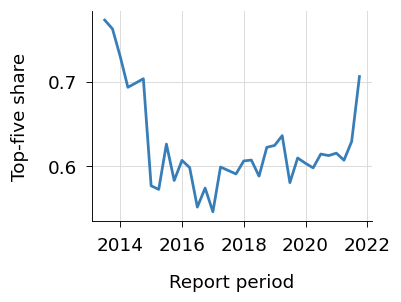

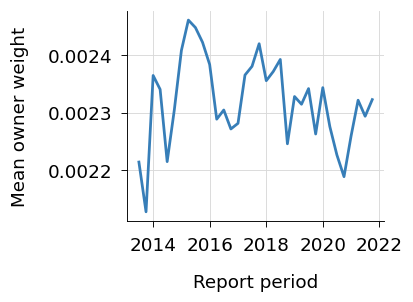

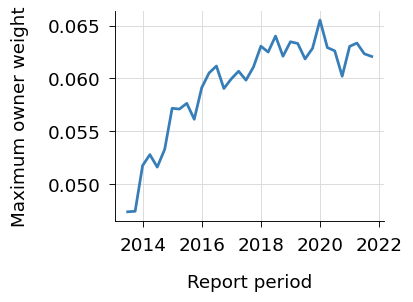

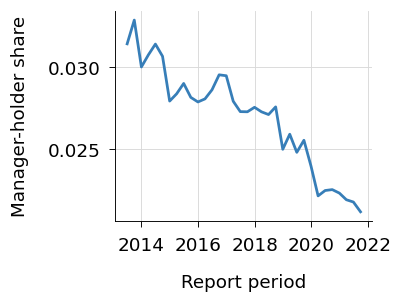

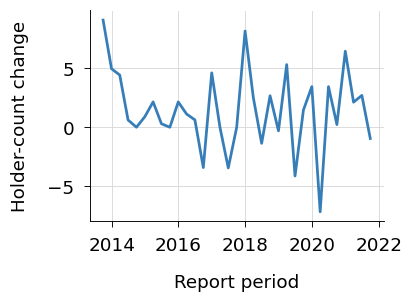

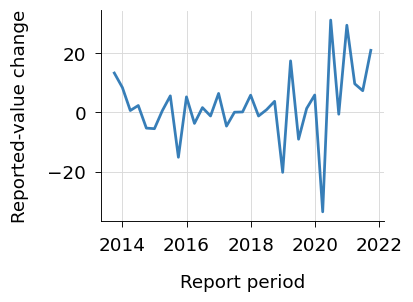

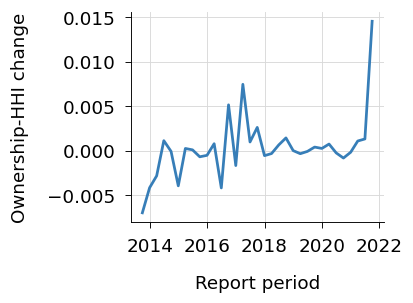

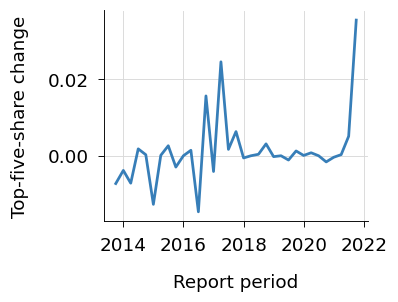

,group,feature,minimum_quarterly_median,maximum_quarterly_median,first_quarter_median,last_quarter_median
0,Market,Market cap,20.117,20.911,20.329,20.911
1,Market,Dollar volume,15.220,16.319,15.220,16.010
2,Market,Return (21d),-0.060,0.078,0.007,0.028
3,Market,Momentum,-0.288,0.704,0.262,0.288
4,Market,Volatility,0.284,1.028,0.301,0.377
5,Market,Downside volatility,0.183,0.730,0.189,0.243
6,Market,Market beta,0.851,1.231,0.995,1.173
7,Market,Past drawdown,0.192,0.563,0.208,0.290
8,Market,Negative-return share,0.444,0.540,0.460,0.476
9,Ownership,Holder count,4.443,4.754,4.443,4.718


In [9]:
temporal_data = training[['report_period', *baseline_features]].copy()
for feature in log_features:
    temporal_data[feature] = np.log1p(temporal_data[feature])

temporal_rows = []
for group_name, features, shape, figure_size, output_name in [
    (
        'Market',
        market_features,
        (3, 3),
        (11, 9),
        '04_00_market_temporal_stability.pdf',
    ),
    (
        'Ownership',
        ownership_features,
        (4, 3),
        (11, 12),
        '04_00_ownership_temporal_stability.pdf',
    ),
]:
    quarterly_medians = (
        temporal_data.groupby('report_period')[features]
        .median()
        .sort_index()
    )
    for feature in features:
        temporal_rows.append(
            {
                'group': group_name,
                'feature': feature_labels[feature],
                'minimum_quarterly_median': quarterly_medians[feature].min(),
                'maximum_quarterly_median': quarterly_medians[feature].max(),
                'first_quarter_median': quarterly_medians[feature].iloc[0],
                'last_quarter_median': quarterly_medians[feature].iloc[-1],
            }
        )

    figure, axes = plt.subplots(*shape, figsize=figure_size, sharex=True)
    for axis, feature in zip(axes.flat, features):
        axis.plot(
            quarterly_medians.index,
            quarterly_medians[feature],
            color=COLOR_PALETTE[0],
        )
        axis_label = feature_labels[feature]
        if feature in log_features:
            axis_label = f'{axis_label} (log1p)'
        axis.set_ylabel(f'{axis_label} median')
        axis.xaxis.set_major_locator(mdates.YearLocator(base=2))
        axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    for axis in axes.flat[len(features):]:
        axis.set_visible(False)

    figure.supxlabel('Report period')
    apply_matplotlib_layout(figure)
    figure.savefig(paths.figures / output_name)
    plt.show()

    output_group = group_name.lower()
    for index, feature in enumerate(features, start=1):
        figure, axis = plt.subplots(figsize=(4, 3))
        axis.plot(
            quarterly_medians.index,
            quarterly_medians[feature],
            color=COLOR_PALETTE[0],
        )
        axis_label = feature_labels[feature]
        if feature in log_features:
            axis_label = f'Log {axis_label.lower()}'
        axis.set_ylabel(axis_label)
        axis.set_xlabel('Report period')
        axis.xaxis.set_major_locator(mdates.YearLocator(base=2))
        axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        apply_matplotlib_layout(figure)
        figure.savefig(
            paths.figures
            / (
                f'04_00_{output_group}_temporal_stability_'
                f'{index:02d}_{feature}.pdf'
            )
        )
        plt.show()

temporal_summary = pd.DataFrame(temporal_rows)
display(temporal_summary.style.format(precision=3))

## 9. Interpretation

- **The training sample is sufficiently broad.** It contains 123,791 stock-quarters for 5,701 securities across 34 quarters from 2013 Q2 through 2021 Q3. No validation or test observations are used in this notebook.
- **Missingness is narrow and explainable.** Sixteen of the 20 predictors are complete. The four ownership-change variables are each missing for 3.02% of training observations, reflecting stocks without a consecutive-quarter predecessor. This supports fitting median imputation on the model's fitting sample rather than deleting observations.
- **Market capitalization is highly dispersed.** Its training-sample median is $0.794 billion, compared with a mean of $7.736 billion and a maximum of $2.528 trillion. Raw skewness is 24.89, while log-transformed skewness is 0.09. The quarterly P10, median, and P90 also move over time, so the predictor contains both cross-sectional and temporal variation.
- **The planned transformations are justified.** Market capitalization, dollar volume, institutional holder count, and total reported value are strongly right-skewed, with raw skewness between 4.18 and 36.77. The reported-value change variable is even more extreme, with skewness of 346.38. The frozen combination of `log1p` for the four nonnegative scale variables and fitting-sample 1st/99th-percentile clipping is therefore appropriate.
- **Several features within each group measure related constructs.** Four market-feature pairs and six ownership-feature pairs have an absolute Spearman correlation of at least 0.80. The strongest include holder count and manager-holder share (0.987), ownership HHI and top-five ownership share (0.967), total and downside volatility (0.942), and market capitalization and dollar volume (0.925). Individual feature effects should therefore not be interpreted as independent economic channels.
- **Historical downside risk provides the strongest univariate signal.** Mean quarterly target correlations are largest for total volatility (0.647), downside volatility (0.646), and past maximum drawdown (0.607). Market capitalization (-0.386), reported institutional value (-0.360), holder count (-0.343), and manager-holder share (-0.343) have the strongest negative associations. These are descriptive training-sample relationships, not causal estimates.
- **The binned relationships are economically ordered.** Mean future drawdown rises by approximately 28 percentage points from the lowest to highest decile of volatility, downside volatility, and past drawdown. It falls by 19.86 percentage points across market-cap deciles and by 15.74 percentage points across holder-count deciles. Ownership concentration has a weaker positive gradient of 6.84 percentage points.
- **The time series show variation rather than an obvious permanent definition break.** Risk measures experience pronounced temporary movements, while median firm size and holder count rise over the training period and ownership concentration changes more gradually. Chronological validation remains essential because the predictor distribution is not stationary.

The separated analyses therefore support the tabular-model design: retain the frozen market and conventional ownership predictors, apply transformations and clipping without looking beyond the fitting sample, impute the four ownership-change variables within the modeling pipeline, and evaluate generalization on the untouched chronological validation and test samples.